# EDA Dataset Pokemon TCG

EDA metadata dan harga tanpa mengunduh semua gambar. Validasi URL dilakukan pada sampel.

In [4]:
from pathlib import Path
import io
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image

root = Path.cwd()
if not (root / 'backend' / 'dataset').exists():
    root = root.parent.parent
csv_path = root / 'backend' / 'dataset' / 'pokemon_cards_dataset.csv'
df = pd.read_csv(csv_path)
print(f'Rows: {len(df):,}; columns: {len(df.columns)}')
display(df.head())

Rows: 19,979; columns: 10


,card_id,name,number,rarity,types,set.name,set.release_date,images.large,prices.cardmarket_trend,prices.tcgplayer_variants.holofoil.market
0,hgss4-1,Aggron,1,Rare Holo,Metal,HS—Triumphant,2010/11/03,https://images.pokemontcg.io/hgss4/1_hires.png,3.64,9.80
1,xy5-1,Weedle,1,Common,Grass,Primal Clash,2015/02/04,https://images.pokemontcg.io/xy5/1_hires.png,0.12,NaN
2,pl1-1,Ampharos,1,Rare Holo,Lightning,Platinum,2009/02/11,https://images.pokemontcg.io/pl1/1_hires.png,5.78,32.44
3,dp3-1,Ampharos,1,Rare Holo,Lightning,Secret Wonders,2007/11/01,https://images.pokemontcg.io/dp3/1_hires.png,6.06,42.56
4,det1-1,Bulbasaur,1,Common,Grass,Detective Pikachu,2019/04/05,https://images.pokemontcg.io/det1/1_hires.png,0.63,1.13


In [5]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_count': df.nunique(dropna=True),
})
display(profile.sort_values('missing_count', ascending=False))
audit = pd.Series({
    'total_rows': len(df),
    'unique_card_id': df['card_id'].nunique(),
    'duplicate_card_id_rows': int(df['card_id'].duplicated().sum()),
    'unique_sets': df['set.name'].nunique(),
    'unique_card_names': df['name'].nunique(),
})
display(audit.to_frame('value'))

,dtype,missing_count,missing_percent,unique_count
prices.tcgplayer_variants.holofoil.market,float64,12842,64.28,3498
types,object,3079,15.41,35
prices.cardmarket_trend,float64,1393,6.97,3202
rarity,object,303,1.52,38
card_id,object,0,0.00,19979
name,object,0,0.00,4381
number,object,0,0.00,1724
set.name,object,0,0.00,175
set.release_date,object,0,0.00,156
images.large,object,0,0.00,19979


,value
total_rows,19979
unique_card_id,19979
duplicate_card_id_rows,0
unique_sets,175
unique_card_names,4381


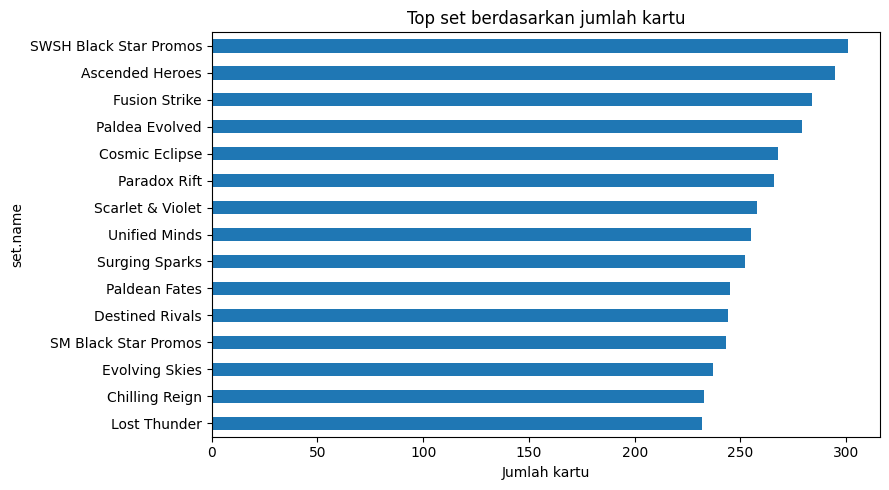

set.name
SWSH Black Star Promos    301
Ascended Heroes           295
Fusion Strike             284
Paldea Evolved            279
Cosmic Eclipse            268
Paradox Rift              266
Scarlet & Violet          258
Unified Minds             255
Surging Sparks            252
Paldean Fates             245
Destined Rivals           244
SM Black Star Promos      243
Evolving Skies            237
Chilling Reign            233
Lost Thunder              232
Name: count, dtype: int64

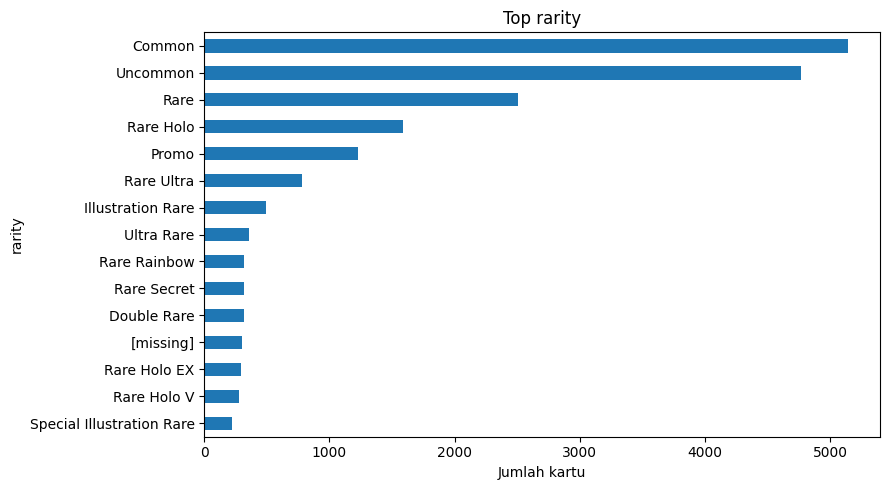

rarity
Common                       5140
Uncommon                     4770
Rare                         2503
Rare Holo                    1584
Promo                        1230
Rare Ultra                    783
Illustration Rare             492
Ultra Rare                    356
Rare Secret                   320
Rare Rainbow                  320
Double Rare                   317
[missing]                     303
Rare Holo EX                  291
Rare Holo V                   278
Special Illustration Rare     222
Name: count, dtype: int64

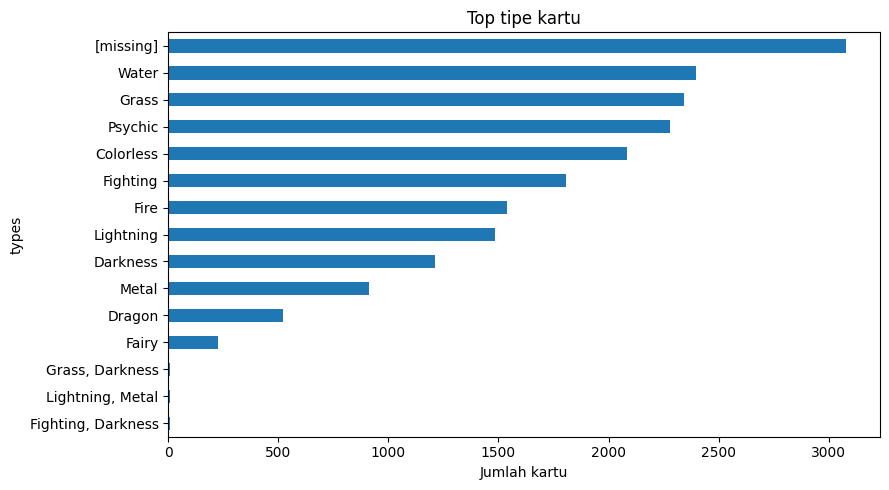

types
[missing]             3079
Water                 2396
Grass                 2344
Psychic               2279
Colorless             2085
Fighting              1805
Fire                  1537
Lightning             1486
Darkness              1212
Metal                  911
Dragon                 521
Fairy                  224
Grass, Darkness         10
Fighting, Darkness       9
Lightning, Metal         9
Name: count, dtype: int64

Kolom 'supertype' tidak tersedia pada CSV; distribusi supertype dilewati.


In [6]:
def plot_top(column, title, n=15):
    counts = df[column].fillna('[missing]').value_counts().head(n).sort_values()
    counts.plot(kind='barh', figsize=(9, 5), title=title)
    plt.xlabel('Jumlah kartu')
    plt.tight_layout()
    plt.show()
    return counts.sort_values(ascending=False)

display(plot_top('set.name', 'Top set berdasarkan jumlah kartu'))
display(plot_top('rarity', 'Top rarity'))
display(plot_top('types', 'Top tipe kartu'))
if 'supertype' in df.columns:
    display(df['supertype'].fillna('[missing]').value_counts().to_frame('count'))
else:
    print("Kolom 'supertype' tidak tersedia pada CSV; distribusi supertype dilewati.")

In [7]:
release_dates = pd.to_datetime(df['set.release_date'], format='%Y/%m/%d', errors='coerce')
print('Rentang rilis:', release_dates.min().date(), 'sampai', release_dates.max().date())
price_columns = ['prices.cardmarket_trend', 'prices.tcgplayer_variants.holofoil.market']
rows = []
for column in price_columns:
    values = pd.to_numeric(df[column], errors='coerce')
    rows.append({
        'field': column,
        'available': int(values.notna().sum()),
        'missing': int(values.isna().sum()),
        'coverage_percent': round(values.notna().mean() * 100, 2),
        'min': values.min(),
        'median': values.median(),
        'mean': values.mean(),
        'max': values.max(),
    })
price_summary = pd.DataFrame(rows)
display(price_summary)

Rentang rilis: 1999-01-09 sampai 2026-07-17


,field,available,missing,coverage_percent,min,median,mean,max
0,prices.cardmarket_trend,18586,1393,93.03,0.00,0.70,12.612460,6312.26
1,prices.tcgplayer_variants.holofoil.market,7137,12842,35.72,0.04,7.26,44.280666,4500.00


In [8]:
# Validasi sampel URL saja; tidak mengunduh seluruh 19k gambar.
SAMPLE_SIZE = 100
sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)
results = []
for _, row in sample.iterrows():
    item = {'card_id': row['card_id'], 'ok': False, 'status': None, 'width': None, 'height': None, 'error': None}
    try:
        response = requests.get(row['images.large'], timeout=15)
        item['status'] = response.status_code
        response.raise_for_status()
        image = Image.open(io.BytesIO(response.content))
        item['ok'] = True
        item['width'], item['height'] = image.size
    except Exception as exc:
        item['error'] = str(exc)
    results.append(item)
url_audit = pd.DataFrame(results)
display(url_audit.head())
display(url_audit['ok'].value_counts().rename('count').to_frame())
display(url_audit[url_audit['ok']][['width', 'height']].describe())

,card_id,ok,status,width,height,error
0,ex4-44,True,200,400,550,None
1,bw3-15,True,200,734,1024,None
2,bw10-57,True,200,734,1024,None
3,sm3-153,True,200,734,1024,None
4,sv5-3,True,200,733,1024,None


,count
ok,
True,100


,width,height
count,100.000000,100.0000
mean,690.890000,960.8600
std,72.620627,106.1751
min,400.000000,550.0000
25%,600.000000,825.0000
50%,733.000000,1024.0000
75%,734.000000,1024.0000
max,734.000000,1024.0000


## Data Card

Gunakan hasil cell untuk mengisi jumlah record, identitas `card_id`, jumlah set, missing value, coverage harga, dan hasil validasi sampel URL. Dataset ini digunakan sebagai reference set untuk image retrieval; dataset Roboflow digunakan terpisah untuk defect classification/detection.